In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.2 MB/s eta 0:00:00


In [2]:
import zipfile
import os

zip_path = "/content/saudi-plates-dt.v1-ver1.yolov8.zip"
extract_path = "/content/saudi_plates_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")
print("Files:", os.listdir(extract_path))

Done
Files: ['valid', 'README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train']


In [3]:
from pathlib import Path

base = Path("/content/saudi_plates_dataset")

for split in ["train", "valid", "test"]:
    images = list((base / split / "images").glob("*"))
    labels = list((base / split / "labels").glob("*"))
    print(split, "images =", len(images), "labels =", len(labels))

train images = 606 labels = 606
valid images = 175 labels = 175
test images = 86 labels = 86


In [4]:
data_yaml = """
train: /content/saudi_plates_dataset/train/images
val: /content/saudi_plates_dataset/valid/images
test: /content/saudi_plates_dataset/test/images

nc: 1
names: ['license_plate']
"""

with open("/content/saudi_plates_dataset/data_fixed.yaml", "w") as f:
    f.write(data_yaml)

print("data_fixed.yaml created")

data_fixed.yaml created


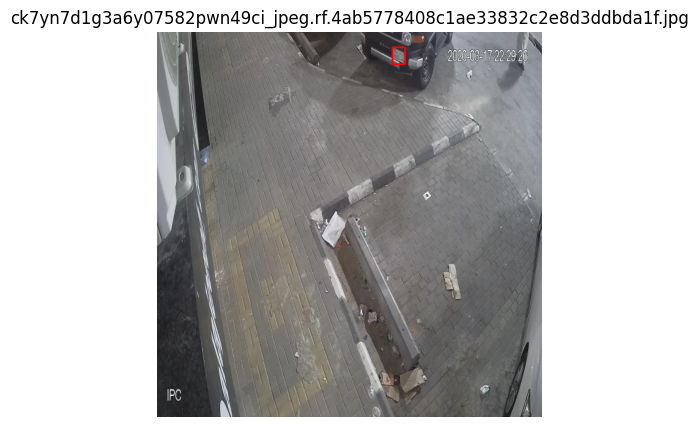

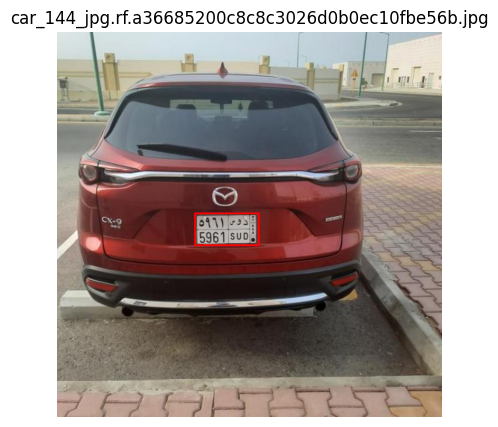

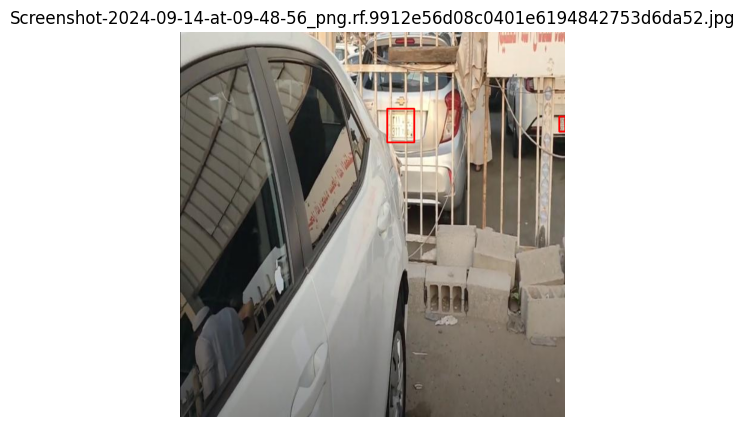

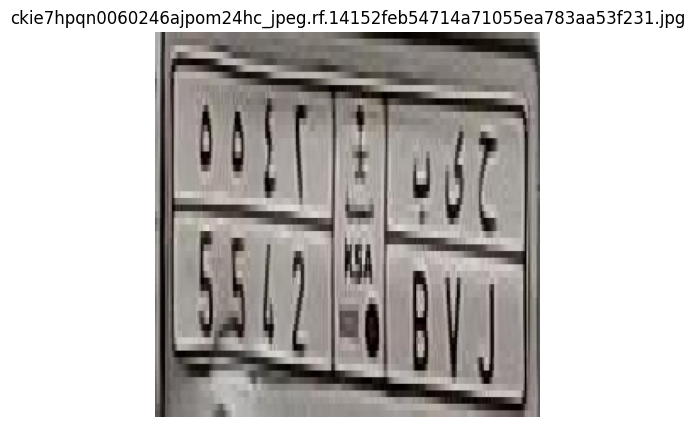

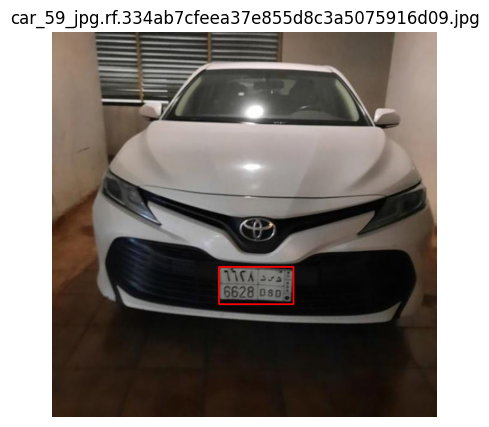

In [5]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

image_dir = Path("/content/saudi_plates_dataset/train/images")
label_dir = Path("/content/saudi_plates_dataset/train/labels")

samples = random.sample(list(image_dir.glob("*")), 5)

for img_path in samples:
    label_path = label_dir / (img_path.stem + ".txt")

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls, x_center, y_center, bw, bh = map(float, parts)
            x_center *= w
            y_center *= h
            bw *= w
            bh *= h

            x1 = int(x_center - bw / 2)
            y1 = int(y_center - bh / 2)
            x2 = int(x_center + bw / 2)
            y2 = int(y_center + bh / 2)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

results = model.train(
    data="/content/saudi_plates_dataset/data_fixed.yaml",
    epochs=50,
    imgsz=960,
    batch=16,
    device=0,
    workers=2,
    project="/content/runs_plate",
    name="plate_detector_v1",
    patience=15,
    save=True,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/saudi_plates_dataset/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False,

In [7]:
best_model = YOLO("/content/runs_plate/plate_detector_v1/weights/best.pt")

metrics = best_model.val(
    data="/content/saudi_plates_dataset/data_fixed.yaml",
    split="test",
    imgsz=960
)

print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3420.1±910.8 MB/s, size: 53.8 KB)
val: Scanning /content/saudi_plates_dataset/test/labels... 86 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86 4.6Kit/s 0.0s
val: New cache created: /content/saudi_plates_dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 114. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 6.5it/s 0.9s
                   all         86        114      0.972       0.92      0.948      0.749
Speed: 2.0ms preprocess, 


image 1/1 /content/saudi_plates_dataset/test/images/car_313_jpg.rf.60b83a2eea9ba9223edd2ffaec3048e3.jpg: 960x960 1 license_plate, 4.5ms
Speed: 1.8ms preprocess, 4.5ms inference, 0.7ms postprocess per image at shape (1, 3, 960, 960)


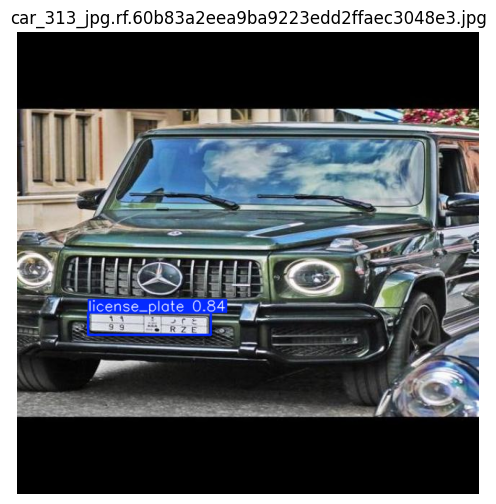


image 1/1 /content/saudi_plates_dataset/test/images/car_226_jpg.rf.40dfc71e6213ddcbae27f34552deba1e.jpg: 960x960 1 license_plate, 4.6ms
Speed: 1.8ms preprocess, 4.6ms inference, 0.7ms postprocess per image at shape (1, 3, 960, 960)


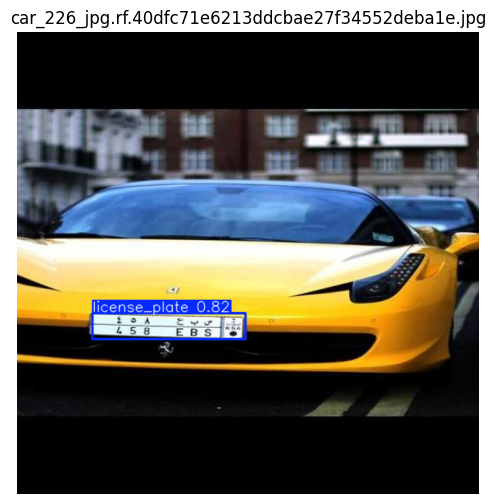


image 1/1 /content/saudi_plates_dataset/test/images/car_156_jpg.rf.ebfd7eb44c6b1b7864c621156f923e94.jpg: 960x960 1 license_plate, 4.6ms
Speed: 1.9ms preprocess, 4.6ms inference, 0.6ms postprocess per image at shape (1, 3, 960, 960)


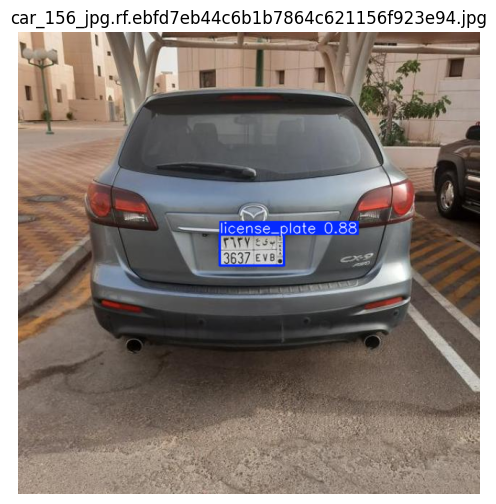


image 1/1 /content/saudi_plates_dataset/test/images/car_312_jpg.rf.0fc865cd86fe960c7206ac61c8c48c94.jpg: 960x960 1 license_plate, 4.5ms
Speed: 1.8ms preprocess, 4.5ms inference, 0.6ms postprocess per image at shape (1, 3, 960, 960)


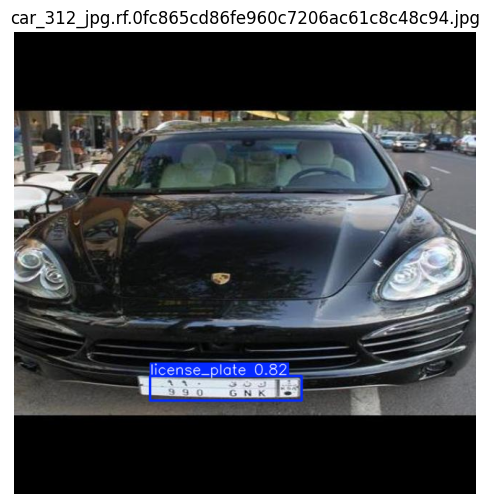


image 1/1 /content/saudi_plates_dataset/test/images/car_184_jpg.rf.432b3ce230eb0429f902452432493af8.jpg: 960x960 1 license_plate, 4.5ms
Speed: 1.8ms preprocess, 4.5ms inference, 0.6ms postprocess per image at shape (1, 3, 960, 960)


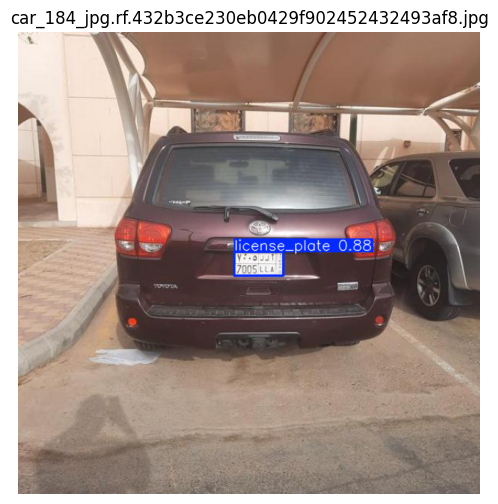

In [8]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import random

model = YOLO("/content/runs_plate/plate_detector_v1/weights/best.pt")

test_images = list(Path("/content/saudi_plates_dataset/test/images").glob("*"))
samples = random.sample(test_images, 5)

for img_path in samples:
    results = model.predict(
        source=str(img_path),
        imgsz=960,
        conf=0.25,
        save=False
    )

    plotted = results[0].plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(plotted)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [9]:
import os
import shutil

os.makedirs("/content/final_artifacts/models/plate_detector", exist_ok=True)

src = "/content/runs_plate/plate_detector_v1/weights/best.pt"
dst = "/content/final_artifacts/models/plate_detector/best.pt"

shutil.copy(src, dst)

print("Saved to:", dst)

Saved to: /content/final_artifacts/models/plate_detector/best.pt


In [10]:
code = r'''
from ultralytics import YOLO
import cv2
import os

class PlateDetector:
    def __init__(self, model_path, conf=0.25, imgsz=960):
        self.model = YOLO(model_path)
        self.conf = conf
        self.imgsz = imgsz

    def detect(self, image_path):
        results = self.model.predict(
            source=image_path,
            conf=self.conf,
            imgsz=self.imgsz,
            save=False,
            verbose=False
        )

        detections = []
        result = results[0]

        if result.boxes is None:
            return detections

        for box in result.boxes:
            xyxy = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls = int(box.cls[0])

            detections.append({
                "bbox": [int(x) for x in xyxy],
                "confidence": conf,
                "class_id": cls,
                "class_name": "license_plate"
            })

        return detections

    def detect_best(self, image_path):
        detections = self.detect(image_path)
        if not detections:
            return None
        detections = sorted(detections, key=lambda x: x["confidence"], reverse=True)
        return detections[0]

    def draw_detections(self, image_path, output_path):
        image = cv2.imread(image_path)
        detections = self.detect(image_path)

        for det in detections:
            x1, y1, x2, y2 = det["bbox"]
            conf = det["confidence"]

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                image,
                f"plate {conf:.2f}",
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        cv2.imwrite(output_path, image)
        return output_path
'''

with open("/content/final_artifacts/plate_detector.py", "w", encoding="utf-8") as f:
    f.write(code)

print("plate_detector.py created")

plate_detector.py created


In [11]:
test_code = r'''
from plate_detector import PlateDetector

model_path = "models/plate_detector/best.pt"
image_path = "test_images/sample.jpg"

detector = PlateDetector(model_path=model_path, conf=0.25, imgsz=960)

detections = detector.detect(image_path)
print(detections)
'''

with open("/content/final_artifacts/test_detector.py", "w", encoding="utf-8") as f:
    f.write(test_code)

print("test_detector.py created")

test_detector.py created


In [12]:
from google.colab import files
files.download('/content/final_artifacts/models/plate_detector/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>